# **Project Name**    - Aerial Object Classification & Detection

##### **Project Type**    - Deep Learning(CNN) & YOLO
##### **Contribution**    - Individual
##### **Team Member 1 -** Koushik Gupta

# **Project Summary -**

The objective of the project is the use of basic deep learning methodologies for detecting aerial objects such as birds and drones. I would try to develop some of the basic models and test their performances by training them on the dataset, such as a basic CNN, ResNet, which has been trained before, for improved accuracy and also an object detection model called YOLO. We would evaluate the performance of each of these models using certain metrics such as accuracy and confusion matrix.

# **Project Links -**

- **GitHub Repository:**
- **Live Streamlit App:**

# **Problem Statement**


This project aims to develop a deep learning-based solution that can classify aerial
images into two categories — Bird or Drone — and optionally perform object
detection to locate and label these objects in real-world scenes.
The solution will help in security surveillance, wildlife protection, and airspace
safety where accurate identification between drones and birds is critical. The project
involves building a Custom CNN classification model, leveraging transfer learning,
and optionally implementing YOLOv8 for real-time object detection. The final solution
will be deployed using Streamlit for interactive use.

In [ ]:
!pip install optuna

In [2]:
from google.colab import files
uploaded = files.upload()

Saving classification_dataset.zip to classification_dataset.zip


In [ ]:
!unzip classification_dataset.zip

In [4]:
import torch
import random
import numpy as np

In [5]:
# Set random seeds for productivity
torch.manual_seed(20)
random.seed(20)
np.random.seed(20)

In [6]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [7]:
train_data = "/content/classification_dataset/train"
test_data = "/content/classification_dataset/test"
val_data = "/content/classification_dataset/valid"

# ***1. Understanding the Dataset***

***Inspect dataset folder structure***

In [8]:
import torchvision.datasets as datasets

train_dataset = datasets.ImageFolder(train_data)

print(train_dataset.classes)

['bird', 'drone']


***Check number of images per class***

In [9]:
from collections import Counter

labels = [label for _, label in train_dataset.samples]
count = Counter(labels)

for i in count:
    print(train_dataset.classes[i], ":", count[i])

bird : 1414
drone : 1248


***Visualize sample images***

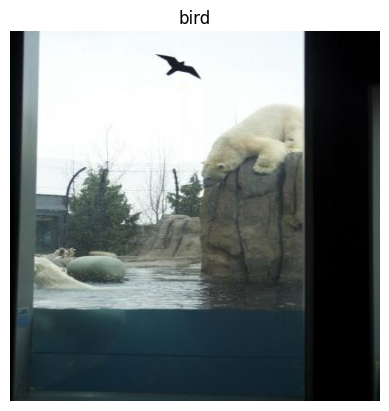

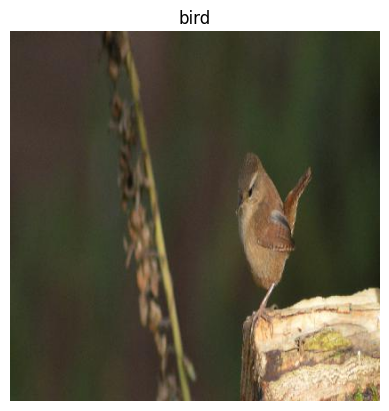

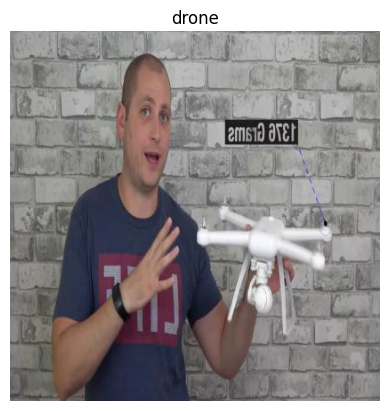

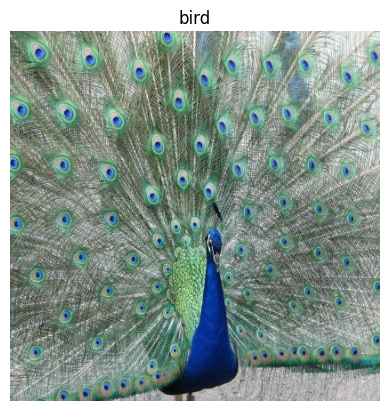

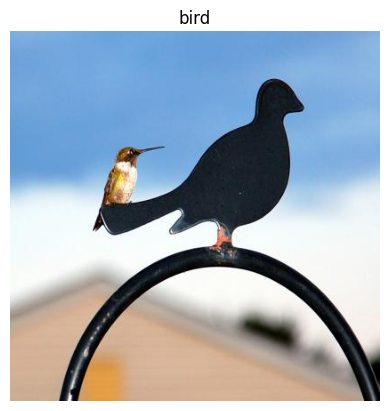

In [10]:
import random
import matplotlib.pyplot as plt

for i in range(5):
    idx = random.randint(0, len(train_dataset)-1)
    img, label = train_dataset[idx]

    plt.imshow(img)
    plt.title(train_dataset.classes[label])
    plt.axis('off')
    plt.show()

The dataset indicated that there are two classes within the image dataset: bird and drone. The images vary in sizes, backgrounds, illumination, and orientation, making the task more realistic but somewhat harder.  There are images that have distinct objects, whereas some are a little harder to detect because of their distances and the similarity in their shapes, whether they are drones or birds.
There are 1414 bird and 1248 drone images. Thus the dataset is balanced in terms of classes, which would help train the model without any bias towards one class or the other.

# ***2. Data Preprocessing***

In [11]:
from torchvision import transforms

test_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # fix size
    transforms.ToTensor(),          # convert to tensor
])

In [12]:
test_dataset  = datasets.ImageFolder(test_data, transform=test_val_transform)
val_dataset   = datasets.ImageFolder(val_data, transform=test_val_transform)

In [13]:
img, label = test_dataset[0]

print(img.shape)
print(img.min(), img.max())

torch.Size([3, 224, 224])
tensor(0.0078) tensor(0.3216)


Here I have transformed the test and validation dataset to fixed size and tensor.

# ***3. Data Augmentation***

In [14]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),

    transforms.RandomHorizontalFlip(p=0.5),   # flipping
    transforms.RandomRotation(15),            # rotation

    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # zoom + cropping

    transforms.ColorJitter(
        brightness=0.2   # brightness
    ),

    transforms.ToTensor(),
])

In [15]:
train_dataset  = datasets.ImageFolder(train_data, transform=train_transform)

In [16]:
img, label = train_dataset[0]

print(img.shape)
print(label)
print(img.min(), img.max())

torch.Size([3, 224, 224])
0
tensor(0.) tensor(0.9255)


I have Augmented the training dataset to correct shape, size with transformations like flipping, rotation, zooming, cropping, brightness.

# ***4. Model Building***

# Custom Model

***Architecture***

In [17]:
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1,1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [19]:
cnn_model = SimpleCNN().to(device)

In [21]:
print(cnn_model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=

***Loss function and Optimizer***

In [ ]:
import torch.optim as optim

loss_fn = nn.CrossEntropyLoss()
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

***DataLoader***

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


***Training Loop***

In [ ]:
from tqdm import tqdm

train_losses = []
val_accuracies = []

epochs = 20

for epoch in range(epochs):
    cnn_model.train()
    running_loss = 0

    print(f"\nEpoch {epoch+1}/{epochs}")

    # Training
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        cnn_optimizer.zero_grad()

        outputs = cnn_model(images)
        loss = loss_fn(outputs, labels)

        loss.backward()
        cnn_optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Loss: {epoch_loss:.4f}")

    # Validation
    cnn_model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = cnn_model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    val_accuracies.append(accuracy)

    print(f"Validation Accuracy: {accuracy:.4f}")


Epoch 1/20


100%|██████████| 84/84 [00:22<00:00,  3.67it/s]


Loss: 0.5859
Validation Accuracy: 0.7014

Epoch 2/20


100%|██████████| 84/84 [00:22<00:00,  3.74it/s]


Loss: 0.5394
Validation Accuracy: 0.6923

Epoch 3/20


...

Loss: 0.3802
Validation Accuracy: 0.8145

Epoch 19/20


100%|██████████| 84/84 [00:22<00:00,  3.75it/s]


Loss: 0.3871
Validation Accuracy: 0.7602

Epoch 20/20


100%|██████████| 84/84 [00:22<00:00,  3.78it/s]


Loss: 0.3775
Validation Accuracy: 0.7715


In [ ]:
# Testing

cnn_model.eval()
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = cnn_model(images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cnn_test_acc = 100 * correct / total
print(f"Test Accuracy: {cnn_test_acc:.2f}%")

Test Accuracy: 84.19%


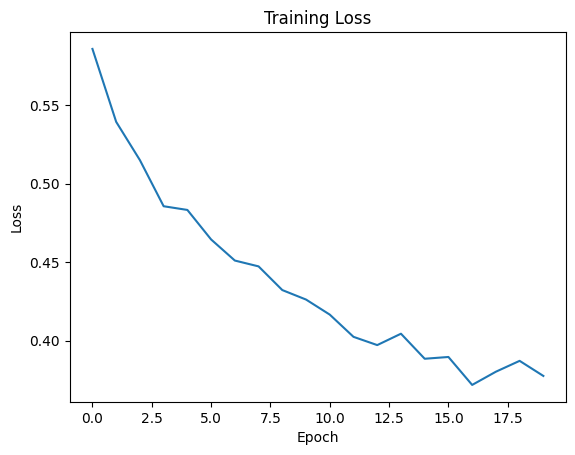

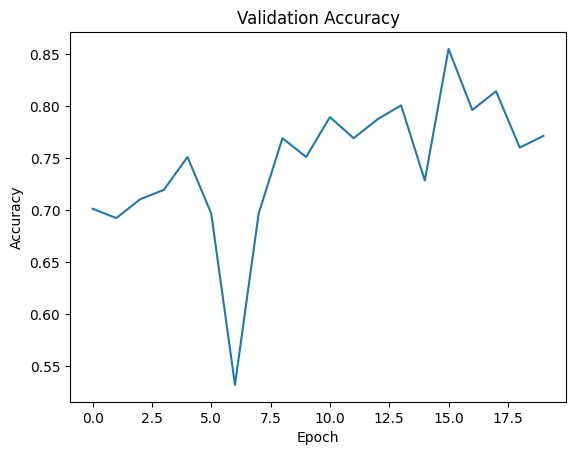

In [ ]:
import matplotlib.pyplot as plt

# Loss
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Accuracy
plt.plot(val_accuracies)
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

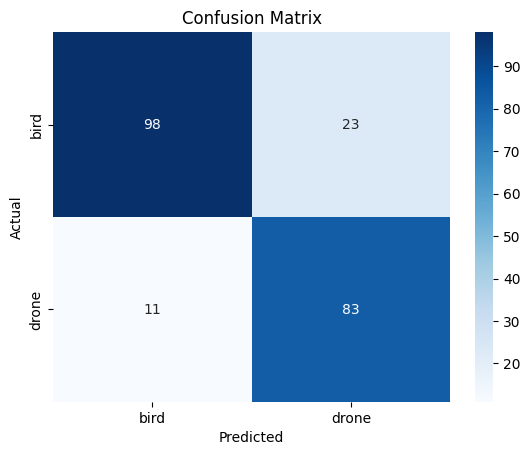

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["bird", "drone"],
            yticklabels=["bird", "drone"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
report = classification_report(all_labels, all_preds, target_names=['bird', 'drone'], output_dict=True)

print(classification_report(all_labels, all_preds, target_names=['bird', 'drone']))

              precision    recall  f1-score   support

        bird       0.90      0.81      0.85       121
       drone       0.78      0.88      0.83        94

    accuracy                           0.84       215
   macro avg       0.84      0.85      0.84       215
weighted avg       0.85      0.84      0.84       215



In [ ]:
results = {}

results["CNN"] = {
    "accuracy": cnn_test_acc,
    "precision": report["weighted avg"]["precision"],
    "recall": report["weighted avg"]["recall"],
    "f1": report["weighted avg"]["f1-score"]
}

print(results["CNN"])

{'accuracy': 86.04651162790698, 'precision': 0.8688610366506475, 'recall': 0.8604651162790697, 'f1': 0.8610165178084516}


In [ ]:
torch.save(cnn_model.state_dict(), "cnn_final.pth")

I have developed a custom architecture for CNN that will classify images into either bird or drone. The proposed architecture utilizes three convolutional layers in which the number of filters will grow incrementally from 32 to 128. By starting with the smaller number of filters, the CNN can learn simpler features such as edges at first while being able to detect more complex features, for instance, shapes, on further layers. To improve the learning process of my network, batch normalization, ReLU activation, and max pooling are added to each convolutional layer. Next, adaptive average pooling is employed to make the sizes of feature maps equal, thus decreasing the amount of parameters that are required for classification in the subsequent stage of the algorithm. Once features are extracted, they undergo a series of fully connected layers with dropout to avoid overfitting.

After that I trained and validated the model and got a testing accuracy of ***84.19%***. Plotted the loss, accuracy graph along with confusion matrix and Classification Report.

# **Transfer Learning(Using Resnet50)**

***Hyperparameter Tuning***

In [22]:
import optuna
from tqdm import tqdm
import torchvision.models as models

def objective(trial):

    # Hyperparameters
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.2, 0.5)
    batch_size = trial.suggest_categorical("batch_size", [32, 64])

    # DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    # Model
    model = models.resnet50(pretrained=True)

    for param in model.parameters():
        param.requires_grad = False

    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(256, 2)
    )

    model = model.to(device)

    # Loss + optimizer
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=lr, weight_decay=weight_decay)

    # Train
    epochs = 3
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

    # Validation
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = 100 * correct / total

    return val_acc

***Finding the best parameters***

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

[I 2026-04-14 15:02:53,404] A new study created in memory with name: no-name-f48a8a0d-8a3e-462d-9cf3-8c3c799fe9ed
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 138MB/s]
[I 2026-04-14 15:03:44,509] Trial 0 finished with value: 95.24886877828054 and parameters: {'lr': 5.3473627038548005e-05, 'weight_decay': 0.00027835213368814963, 'dropout': 0.21779860384685168, 'batch_size': 32}. Best is trial 0 with value: 95.24886877828054.
[I 2026-04-14 15:04:33,809] Trial 1 finished with value: 96.38009049773756 and parameters: {'lr': 0.0007617809652180904, 'weight_decay': 0.00010578944425143982, 'dropout': 0.450293041042289, 'batch_size': 32}. Best is trial 1 with value: 96.38009049773756.
[I 2026-04-14 15:05:23,410] Trial 2 finished with value: 94.11764705882354 and parameters: {'lr': 6.066335076016455e-05, 'weight_decay': 5.92536047055244e-06, 'dropout': 0.42971025167069093, 'batch_size': 64}. Best is trial 1 with value: 96.38009049773756.
[I 2026-04-14 15:06:11,994] Trial 3 finished with value: 94.34389140271493 and parameters: {'lr': 0.0002853785903665656, 'weight_decay': 2.1668054090814513e-06, 'dropout': 0.

***Final Training Phase***

In [ ]:
# Get the best parameters
best_params = study.best_params
print("Best Params:", best_params)

Best Params: {'lr': 0.0007617809652180904, 'weight_decay': 0.00010578944425143982, 'dropout': 0.450293041042289, 'batch_size': 32}


In [ ]:
# Data Loading

train_loader = DataLoader(
    train_dataset,
    batch_size=best_params["batch_size"],
    shuffle=True,
    num_workers=2,
    pin_memory=True
)


val_loader = DataLoader(
    val_dataset,
    batch_size=best_params["batch_size"],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=best_params["batch_size"],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
# Model Loading
from torchvision.models import ResNet50_Weights

resnet_model = models.resnet50(weights=ResNet50_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 154MB/s]


In [ ]:
# Freezing Convolution Layers
for param in resnet_model.parameters():
    param.requires_grad = False

In [ ]:
# Defining fully connected layer architecture using the best parameters
num_features = resnet_model.fc.in_features
resnet_model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(best_params["dropout"]),
    nn.Linear(256, 2)
)

In [ ]:
# Loading Model to Device
resnet_model = resnet_model.to(device)

In [ ]:
# Defining Loss
loss_fn = nn.CrossEntropyLoss()

In [ ]:
# Defing Optimizer
resnet_optimizer = optim.Adam(
    resnet_model.fc.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"]
)

In [ ]:
resnet_train_losses = []
resnet_val_accuracies = []

epochs = 20

for epoch in range(epochs):
    resnet_model.train()
    running_loss = 0

    print(f"\nEpoch {epoch+1}/{epochs}")

    # Training
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        resnet_optimizer.zero_grad()

        outputs = resnet_model(images)
        loss = loss_fn(outputs, labels)

        loss.backward()
        resnet_optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    resnet_train_losses.append(epoch_loss)

    print(f"Loss: {epoch_loss:.4f}")

    # Validation
    resnet_model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = resnet_model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    resnet_val_accuracies.append(accuracy)

    print(f"Validation Accuracy: {accuracy:.4f}")


Epoch 1/20


100%|██████████| 84/84 [00:17<00:00,  4.91it/s]

Loss: 0.1376


Validation Accuracy: 0.9842

Epoch 2/20


100%|██████████| 84/84 [00:16<00:00,  4.98it/s]

...

Loss: 0.0099


Validation Accuracy: 0.9774

Epoch 20/20


100%|██████████| 84/84 [00:16<00:00,  5.03it/s]

Loss: 0.0146


Validation Accuracy: 0.9774


In [ ]:
resnet_model.eval()
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = resnet_model(images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

resnet_test_acc = 100 * correct / total
print(f"Test Accuracy: {resnet_test_acc:.2f}%")

Test Accuracy: 98.60%


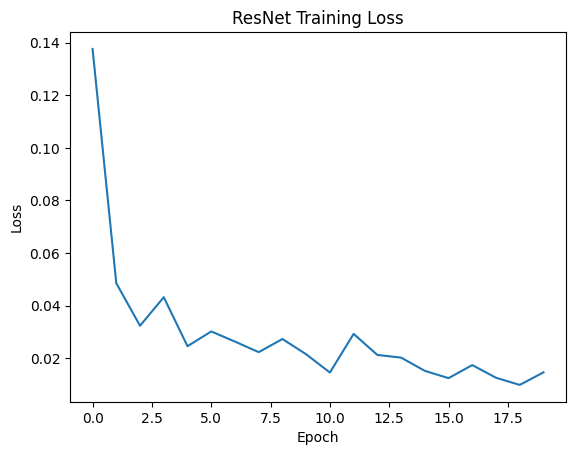

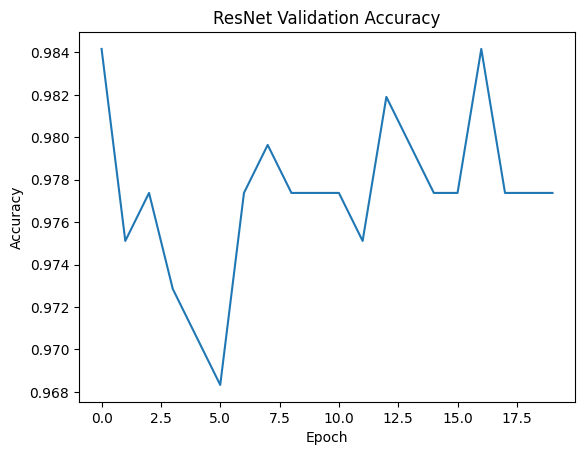

In [ ]:
# Loss
plt.plot(resnet_train_losses)
plt.title("ResNet Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Accuracy
plt.plot(resnet_val_accuracies)
plt.title("ResNet Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

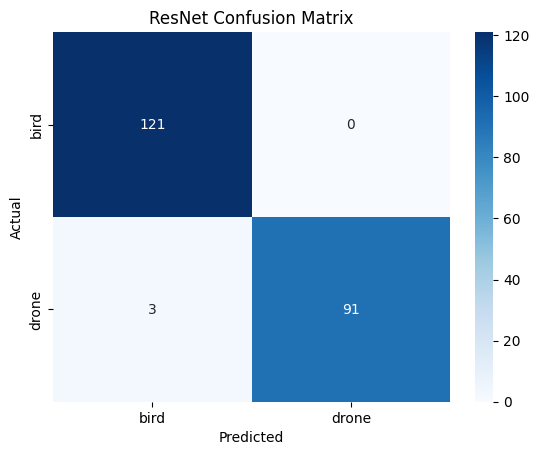

              precision    recall  f1-score   support

        bird       0.98      1.00      0.99       121
       drone       1.00      0.97      0.98        94

    accuracy                           0.99       215
   macro avg       0.99      0.98      0.99       215
weighted avg       0.99      0.99      0.99       215



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["bird", "drone"],
            yticklabels=["bird", "drone"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet Confusion Matrix")
plt.show()

print(classification_report(all_labels, all_preds, target_names=['bird', 'drone']))

In [ ]:
resnet_report = classification_report(all_labels, all_preds, target_names=['bird', 'drone'], output_dict=True)

print(classification_report(all_labels, all_preds, target_names=['bird', 'drone']))

              precision    recall  f1-score   support

        bird       0.98      1.00      0.99       121
       drone       1.00      0.97      0.98        94

    accuracy                           0.99       215
   macro avg       0.99      0.98      0.99       215
weighted avg       0.99      0.99      0.99       215



In [ ]:
results["ResNet"] = {
    "accuracy": resnet_test_acc,
    "precision": resnet_report["weighted avg"]["precision"],
    "recall": resnet_report["weighted avg"]["recall"],
    "f1": resnet_report["weighted avg"]["f1-score"]
}

print(results["ResNet"])

{'accuracy': 98.6046511627907, 'precision': 0.986384096024006, 'recall': 0.986046511627907, 'f1': 0.9860188047563463}


In [ ]:
torch.save(resnet_model.state_dict(), "resnet_final.pth")

For the transfer learning part, I used the ResNet50 model as the base architecture. The pre-trained weights were loaded, and the final fully connected layer was modified to match our classification task with two output classes: bird and drone. The model was then trained on our dataset by defining appropriate hyperparameters such as learning rate, optimizer, batch size, and number of epochs. During training, the model learned to adapt the pre-trained features to our specific dataset.

After training, the model was evaluated using a validation set to monitor its performance. The training loss and validation accuracy were recorded for each epoch and later plotted as graphs to analyze how well the model was learning and converging over time.

Finally, the trained model was tested on a separate test dataset. Predictions were collected and used to generate a confusion matrix and classification report, which helped in understanding the model’s accuracy and misclassification patterns.


***YOLO Model***

In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model = YOLO("yolov8m.pt")

In [ ]:
model.train(
    data="/content/object_detection_Dataset/data.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    fliplr=0.6,
    scale=0.5,
    translate=0.1,
    patience=10
)

In [ ]:
model = YOLO("/content/runs/detect/train3/weights/last.pt")

model.train(
    resume=True
)

In [ ]:
model = YOLO("runs/detect/train3/weights/best.pt")

model.train(
    data="/content/object_detection_Dataset/data.yaml",
    epochs=20,
    imgsz=640,
    batch=8,
    patience=10
)

In [ ]:
model = YOLO("runs/detect/train4/weights/best.pt")

In [ ]:
metrics = model.val(data="/content/object_detection_Dataset/data.yaml")

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 693.8±199.9 MB/s, size: 27.8 KB)
val: Scanning /content/object_detection_Dataset/valid/labels.cache... 448 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 448/448 110.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.1it/s 13.6s
                   all        448        663      0.833      0.768      0.807      0.518
                  Bird        217        414      0.794       0.64      0.705      0.411
                 drone        225        249      0.872      0.896      0.909      0.625
Speed: 2.5ms preprocess, 20.9ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/val5


In [ ]:
precision = metrics.box.mp
recall = metrics.box.mr
map50 = metrics.box.map50

results["YOLO"] = {
    "accuracy": map50,
    "precision": precision,
    "recall": recall,
    "f1": 2 * (precision * recall) / (precision + recall)
}

print(results["YOLO"])

{'accuracy': np.float64(0.8071273970417825), 'precision': np.float64(0.833031861224304), 'recall': np.float64(0.7678394738373785), 'f1': np.float64(0.7991082506172754)}


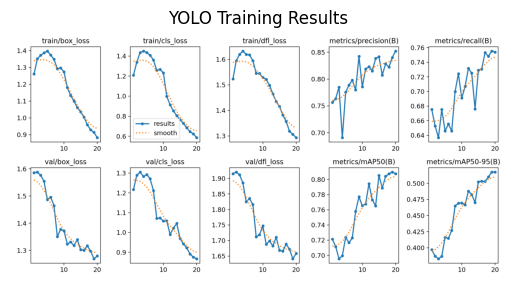

In [ ]:
import matplotlib.pyplot as plt
import cv2

def show_image(path, title):
    img = cv2.imread(path)
    if img is None:
        print(f"Error: Image not found at {path}")
        return
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

# Main Graph
show_image("/content/runs/detect/train4/results.png", "YOLO Training Results")

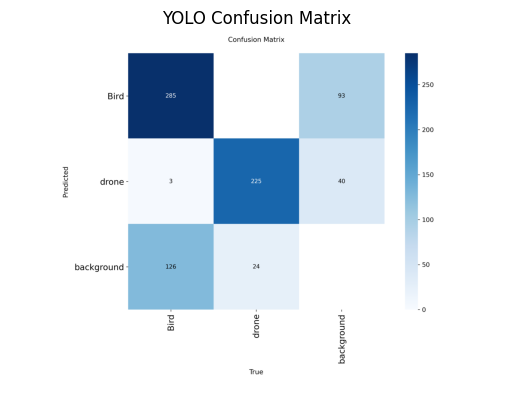

In [ ]:
# Confusion Matrix
show_image("/content/runs/detect/train4/confusion_matrix.png", "YOLO Confusion Matrix")

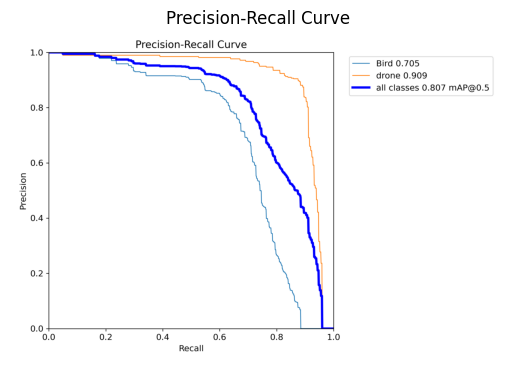

In [ ]:
# PR Curve
show_image("/content/runs/detect/train4/BoxPR_curve.png", "Precision-Recall Curve")

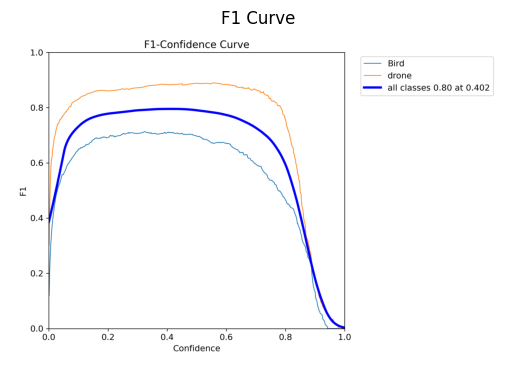

In [ ]:
# F1 Curve
show_image("/content/runs/detect/train4/BoxF1_curve.png", "F1 Curve")

In case of object detection, I used the YOLO (You Only Look Once) method which is a pre-trained version that had been trained on my custom dataset of birds and drones with bounding box information for each object. The dataset had been prepared in the necessary format and trained by adjusting the parameters such as epochs, image size, batch size, and learning rate. In this way, YOLO learns to classify the object and determine its location in the picture.

In addition, once the training process was completed, the evaluation results, such as loss, precision, recall, and mAP had been calculated automatically, and visualized through the built-in graphs.

The final step involves testing the trained YOLO model on the validation data. As an outcome, I got detection and localization of the object with bounding boxes for each object accompanied by their labels and confusion matrix.

# ***5. Model Comparison***

In [ ]:
results

{'CNN': {'accuracy': 87.44186046511628,
  'precision': 0.8839109379214286,
  'recall': 0.8744186046511628,
  'f1': 0.8749091463313085},
 'ResNet': {'accuracy': 99.06976744186046,
  'precision': 0.9908489317451314,
  'recall': 0.9906976744186047,
  'f1': 0.9906857862006485},
 'YOLO': {'accuracy': np.float64(0.8071273970417825),
  'precision': np.float64(0.833031861224304),
  'recall': np.float64(0.7678394738373785),
  'f1': np.float64(0.7991082506172754)}}

In [ ]:
print("===== MODEL COMPARISON =====\n")

for model in results:
    print(model)
    print("Accuracy :", round(results[model]["accuracy"], 4))
    print("Precision:", round(results[model]["precision"], 4))
    print("Recall   :", round(results[model]["recall"], 4))
    print("F1 Score :", round(results[model]["f1"], 4))
    print("-" * 30)

===== MODEL COMPARISON =====

CNN
Accuracy : 87.4419
Precision: 0.8839
Recall   : 0.8744
F1 Score : 0.8749
------------------------------
ResNet
Accuracy : 99.0698
Precision: 0.9908
Recall   : 0.9907
F1 Score : 0.9907
------------------------------
YOLO
Accuracy : 0.8071
Precision: 0.833
Recall   : 0.7678
F1 Score : 0.7991
------------------------------


In [ ]:
best_model = None
best_acc = 0

for model in results:
    if results[model]["accuracy"] > best_acc:
        best_acc = results[model]["accuracy"]
        best_model = model

print("\nBest Model based on Accuracy:", best_model)


Best Model based on Accuracy: ResNet


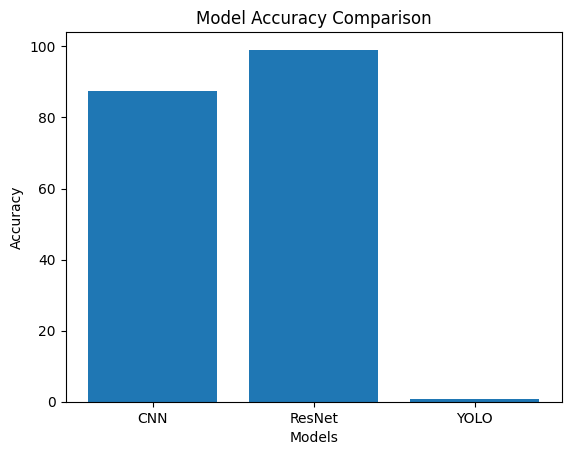

In [ ]:
import matplotlib.pyplot as plt

models = list(results.keys())
accuracies = [results[m]["accuracy"] for m in models]

plt.figure()
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

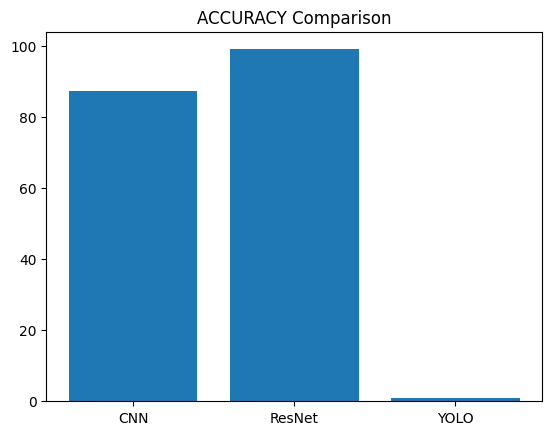

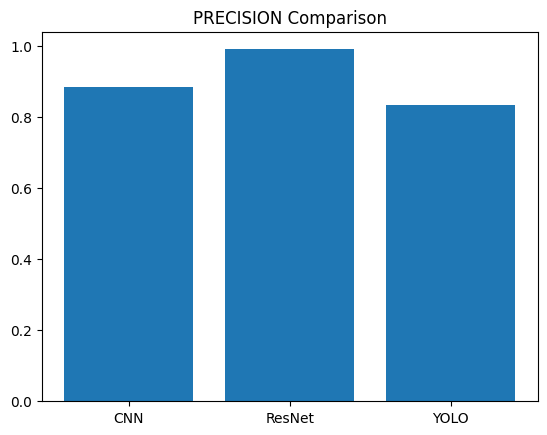

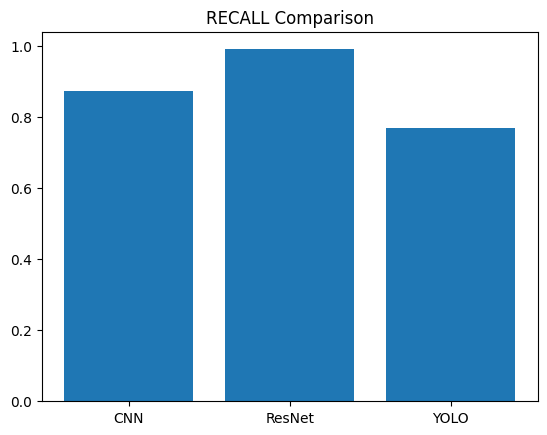

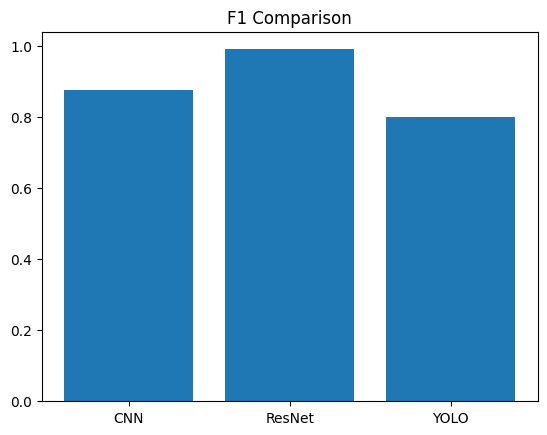

In [ ]:
metrics = ["accuracy", "precision", "recall", "f1"]

for metric in metrics:
    values = [results[m][metric] for m in results]

    plt.figure()
    plt.bar(results.keys(), values)
    plt.title(metric.upper() + " Comparison")
    plt.show()

Following the analysis of the results obtained from the three different models, a comparative study was done based on their performance metrics. Custom Convolutional Neural Network attained an accuracy of about 87.44% with precision, recall, and F1-score around 0.87–0.88. Hence, it can be said that the model works relatively well but is unable to learn some intricate features of the images.

ResNet50 model outperformed all the other models and achieved an accuracy of about 99.07% with precision, recall, and F1 score all around 0.99. Thus, it indicates the model has exceptionally high performance and consistency, mainly because of the use of transfer learning techniques and deeper neural network.

YOLO model, which is employed in object detection, has a precision score of 0.833, a recall score of 0.768, and an F1 score of 0.799. Its accuracy (mAP50) score is about 0.807. It can be noted that although the accuracy of the model is lower than ResNet, it is an excellent model for real-time object detection and localization.

Thus it can be concluded that ResNet50 model is the best for image classification problems, whereas YOLO model is better for object detection tasks.

# ***6. Streamlit Dahboard***

In [ ]:
! pip install streamlit

In [ ]:
import streamlit as st
from PIL import Image
import torch
import torch.nn as nn
from torchvision import transforms, models
from ultralytics import YOLO

st.title("Bird vs Drone Detection System")

# CNN Architecture
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1,1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# CNN
cnn_model = SimpleCNN()
cnn_model.load_state_dict(torch.load("cnn_final.pth", map_location="cpu"))
cnn_model.eval()

# ResNet
resnet_model = models.resnet50(weights=None)

resnet_model.fc = nn.Sequential(
    nn.Linear(resnet_model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 2)
)

resnet_model.load_state_dict(torch.load("resnet_final.pth", map_location="cpu"))
resnet_model.eval()

# YOLO
yolo_model = YOLO("best.pt")



transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

classes = ["bird", "drone"]



uploaded_file = st.file_uploader("Upload an Image", type=["jpg", "png", "jpeg"])

if uploaded_file is not None:

    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption="Uploaded Image")

    img = transform(image).unsqueeze(0)

    with torch.no_grad():
        output = cnn_model(img)
        probs = torch.softmax(output, dim=1)
        conf, pred = torch.max(probs, 1)

    st.write(f"### CNN Prediction: {classes[pred.item()]} ({conf.item()*100:.2f}%)")


    with torch.no_grad():
        output = resnet_model(img)
        probs = torch.softmax(output, dim=1)
        conf, pred = torch.max(probs, 1)

    st.write(f"### ResNet Prediction: {classes[pred.item()]} ({conf.item()*100:.2f}%)")


    results = yolo_model(image)

    st.write("### YOLO Detection:")
    st.image(results[0].plot(), caption="YOLO Output")

A basic Streamlit web application was created to run and evaluate the performance of the three models mentioned above. The end user can upload the image, and this image will be analyzed and classified using both the custom CNN and ResNet models, with the result being displayed in terms of the output class (drone or bird) and its level of confidence. At the same time, the image will also be used to analyze the YOLO model by detecting and localizing objects within the image with bounding boxes.

# ***7. Conclusion***

In this project, various deep learning techniques have been used for classification and object detection of aerial objects such as birds and drones. First, a customized CNN architecture was developed as a baseline model. Then, a transfer learning technique based on the ResNet50 model was used, and finally, an object detection model using YOLO was developed. Based on the findings of this research, the proposed customized CNN gave reasonable accuracy. However, the performance of the ResNet model was much better in terms of accuracy and stability. Although the accuracy rate of the YOLO model was somewhat lower than that of other models, it offered the benefit of real-time object detection.